# NeuroSeek-MoE: ArXiv Healthcare+ML Paper Training Pipeline

Complete pipeline for training language models on healthcare+ML papers from ArXiv.

**Features:**
- ArXiv paper collection (30-40k papers) via free ArXiv API
- Direct paper download using NeMo Curator's free download_arxiv() function
- NeMo Curator curation with custom healthcare stages (Linux/Colab only)
- Healthcare-specific preprocessing
- SentencePiece tokenizer training
- Model training with Colab-optimized settings
- Evaluation and inference export

**NeMo Curator Pipeline:**
- Uses `download_arxiv()` for FREE direct ArXiv access (no AWS needed)
- Custom `HealthcareFilterStage` for text cleaning and domain classification
- Custom `HealthcareQualityFilterStage` for deduplication and quality checks
- Custom `HealthcareJsonlWriter` for formatted output

**Requirements:**
- NeMo Curator: Requires Linux (Colab uses Linux, so it will work)
- No AWS credentials needed (uses free ArXiv API)
- No charges or payments required

**Note:** On non-Linux platforms, the pipeline falls back to basic preprocessing.


## 1. Setup Environment


In [183]:
# Mount Google Drive (optional - for persistent storage)
from google.colab import drive
drive.mount('/content/drive')

# Set working directory
import os
WORK_DIR = '/content/neuroMOE'
os.makedirs(WORK_DIR, exist_ok=True)
os.chdir(WORK_DIR)
print(f"Working directory: {WORK_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/neuroMOE


### Restore Data and Checkpoints from Google Drive

If you have previously saved data and checkpoints to Google Drive, restore them here to resume your pipeline.

In [ ]:
# Restore data and checkpoints from Google Drive
import shutil
from pathlib import Path
# Configure your Google Drive path where data/checkpoints are saved
# Default: /content/drive/MyDrive/neuroMOE_results
DRIVE_BACKUP_PATH = "/content/drive/MyDrive/neuroMOE_results"  # Change this to your backup location
# What to restore (set to True to restore)
RESTORE_DATA = True  # Restore collected papers, extracted texts, curated datasets
RESTORE_CHECKPOINTS = True  # Restore training checkpoints
RESTORE_TOKENIZER = True  # Restore trained tokenizer
RESTORE_CONFIG = False  # Restore config.yaml (usually want latest from repo)
def restore_from_drive(drive_path, work_dir, restore_data=True, restore_checkpoints=True, restore_tokenizer=True, restore_config=False):
    """Restore data and checkpoints from Google Drive."""
    drive_path = Path(drive_path)
    work_dir = Path(work_dir)
    if not drive_path.exists():
        print(f"Drive backup path not found: {drive_path}")
        print("   Skipping restore. If this is your first run, this is expected.")
        return False
    restored = False
    # Restore data directory
    if restore_data:
        data_backup = drive_path / "data"
        data_target = work_dir / "data"
        if data_backup.exists():
            print(f"Restoring data from {data_backup}...")
            # Debug: count files in backup
            backup_data_files = [f for f in data_backup.rglob("*") if f.is_file()]
            print(f"   Debug: Found {len(backup_data_files)} files in backup data directory")
            # Count by type
            backup_txt = [f for f in backup_data_files if f.suffix == ".txt"]
            backup_jsonl = [f for f in backup_data_files if f.suffix == ".jsonl"]
            print(f"   Debug: Backup contains {len(backup_txt)} .txt files, {len(backup_jsonl)} .jsonl files")
        if data_target.exists():
            print(f"   Target directory exists, merging...")
            files_restored_count = 0
            # Debug: count files in backup
            backup_data_files = [f for f in data_backup.rglob("*") if f.is_file()]
            print(f"   Debug: Found {len(backup_data_files)} files in backup data directory")
            backup_txt = [f for f in backup_data_files if f.suffix == ".txt"]
            backup_jsonl = [f for f in backup_data_files if f.suffix == ".jsonl"]
            print(f"   Debug: Backup contains {len(backup_txt)} .txt files, {len(backup_jsonl)} .jsonl files")
            # Merge: copy files that don't exist in target
            for item in data_backup.rglob("*"):
                if item.is_file():
                    rel_path = item.relative_to(data_backup)
                    target_file = data_target / rel_path
                    if not target_file.exists():
                        target_file.parent.mkdir(parents=True, exist_ok=True)
                        shutil.copy2(item, target_file)
                        files_restored_count += 1
                        print(f"   Restored: {rel_path}")
            # Debug: count files after restore
            restored_data_files = [f for f in data_target.rglob("*") if f.is_file()]
            restored_txt = [f for f in restored_data_files if f.suffix == ".txt"]
            restored_jsonl = [f for f in restored_data_files if f.suffix == ".jsonl"]
            print(f"   Debug: After restore, target has {len(restored_data_files)} total files")
            print(f"   Debug: Target contains {len(restored_txt)} .txt files, {len(restored_jsonl)} .jsonl files")
            print(f"   Debug: Restored {files_restored_count} new files (merged with existing)")
        else:
    # Restore checkpoints
            restored = True
    if restore_checkpoints:
        checkpoints_backup = drive_path / "checkpoints"
        checkpoints_target = work_dir / "checkpoints"
        if checkpoints_backup.exists():
            print(f"Restoring checkpoints from {checkpoints_backup}...")
            # Debug: list what files exist in backup
            backup_files = list(checkpoints_backup.rglob("*"))
            backup_files_list = [f for f in backup_files if f.is_file()]
            print(f"   Debug: Found {len(backup_files_list)} files in backup directory")
            if backup_files_list:
                print(f"   Debug: Sample backup files: {[str(f.relative_to(checkpoints_backup)) for f in backup_files_list[:5]]}")
            if checkpoints_target.exists():
                print(f"   Target directory exists, merging...")
                # Debug: show what we're restoring
                files_to_restore = []
                for item in checkpoints_backup.rglob("*"):
                    if item.is_file():
                        rel_path = item.relative_to(checkpoints_backup)
                        # Fix: handle nested "checkpoints" directory structure
                        if len(rel_path.parts) > 0 and rel_path.parts[0] == "checkpoints":
                            rel_path = Path(*rel_path.parts[1:])  # Remove "checkpoints" prefix
                        target_file = checkpoints_target / rel_path
                        if not target_file.exists():
                            target_file.parent.mkdir(parents=True, exist_ok=True)
                            shutil.copy2(item, target_file)
                            files_to_restore.append(target_file)
                            print(f"   Restored: {rel_path}")
                # Debug: verify what was restored
                restored_files = list(checkpoints_target.rglob("*.pt"))
                print(f"   Debug: After restore, found {len(restored_files)} .pt files in target")
                if restored_files:
                    print(f"   Debug: Restored checkpoint files: {[f.name for f in restored_files]}")
            else:
                checkpoints_target.mkdir(parents=True, exist_ok=True)
                shutil.copytree(checkpoints_backup, checkpoints_target, dirs_exist_ok=True)
                print(f"   Restored entire checkpoints directory")
            restored = True
        else:
            print(f"   No checkpoints backup found at {checkpoints_backup}")
    if restore_tokenizer:
        tokenizer_files = ["healthcare_tokenizer.model", "healthcare_tokenizer.vocab"]
        data_dir = work_dir / "data" / "arxiv"
        for tokenizer_file in tokenizer_files:
            backup_file = drive_path / "tokenizer" / tokenizer_file
            if backup_file.exists():
                target_file = data_dir / tokenizer_file
                data_dir.mkdir(parents=True, exist_ok=True)
                shutil.copy2(backup_file, target_file)
                print(f"   Restored tokenizer: {tokenizer_file}")
        restored = True
        restored = True
    # Restore config (optional)
    if restore_config:
        config_backup = drive_path / "config.yaml"
        if config_backup.exists():
            config_target = work_dir / "config.yaml"
            shutil.copy2(config_backup, config_target)
            print(f"   Restored config.yaml")
        restored = True
        restored = True
    if restored:
        print("\nRestore complete!")
        print("   Your pipeline will resume from the restored checkpoints.")
    else:
        print("\nNo backups found to restore.")
        print("   This is normal for first-time runs.")
    # Print summary
    print("\n" + "=" * 60)
    print("Restore Summary:")
    print("=" * 60)
    
    # Check what exists
    data_target = work_dir / "data"
    checkpoints_target = work_dir / "checkpoints"
    tokenizer_dir = work_dir / "data" / "arxiv"
    
    if data_target.exists():
        # Count all files in data directory (not just .jsonl and .txt)
        data_files = [f for f in data_target.rglob("*") if f.is_file()]
        # Count by file type
        txt_files = [f for f in data_files if f.suffix == ".txt"]
        jsonl_files = [f for f in data_files if f.suffix == ".jsonl"]
        other_files = [f for f in data_files if f.suffix not in [".txt", ".jsonl"]]
        print(f"Data directory: {len(data_files)} total files found")
        print(f"   Breakdown: {len(txt_files)} .txt, {len(jsonl_files)} .jsonl, {len(other_files)} other")
        if (data_target / "arxiv_papers.jsonl").exists():
            with open(data_target / "arxiv_papers.jsonl", "r") as f:
                paper_count = sum(1 for line in f if line.strip())
            print(f"   Papers collected: {paper_count}")
    
    if checkpoints_target.exists():
        # Debug: list all files in checkpoints directory
        all_checkpoint_files = list(checkpoints_target.rglob("*"))
        all_files = [f for f in all_checkpoint_files if f.is_file()]
        print(f"   Debug: Found {len(all_files)} total files in checkpoints directory")
        if all_files:
            print(f"   Debug: Sample files: {[f.name for f in all_files[:5]]}")
        
        # Search for checkpoint files with multiple patterns
        checkpoint_files = list(checkpoints_target.rglob("step_*.pt"))  # Search recursively
        # Also check for files that might be in subdirectories
        if not checkpoint_files:
            # Try alternative patterns
            checkpoint_files = list(checkpoints_target.rglob("*.pt"))
            checkpoint_files = [f for f in checkpoint_files if "step" in f.name.lower()]
        print(f"Checkpoints: {len(checkpoint_files)} checkpoint files")
        if checkpoint_files:
            latest = max(checkpoint_files, key=lambda p: p.stat().st_mtime)
            print(f"   Latest: {latest.name}")
    
    if tokenizer_dir.exists():
        tokenizer_files = ["healthcare_tokenizer.model", "healthcare_tokenizer.vocab"]
        found = [f for f in tokenizer_files if (tokenizer_dir / f).exists()]
        print(f"Tokenizer: {len(found)}/{len(tokenizer_files)} files")
    
    print("=" * 60)
    
    return restored
# Run restore
restore_from_drive(
    drive_path=DRIVE_BACKUP_PATH,
    work_dir=WORK_DIR,
    restore_data=RESTORE_DATA,
    restore_checkpoints=RESTORE_CHECKPOINTS,
    restore_tokenizer=RESTORE_TOKENIZER,
    restore_config=RESTORE_CONFIG
)

In [184]:
# Clone repository from GitHub
import sys
import subprocess
import os

# Update this URL to your repository
REPO_URL = "https://github.com/oleeveeuh/neuroseekmoe.git"

# Clone the repository
if not os.path.exists(os.path.join(WORK_DIR, ".git")):
    print(f" Cloning repository from {REPO_URL}...")
    subprocess.run(["git", "clone", REPO_URL, "."], cwd=WORK_DIR, check=True)
    print("Repository cloned successfully")
else:
    print("Repository already exists. Ensuring clean state and pulling latest changes...")
    # Discard any local changes that might prevent pulling
    subprocess.run(["git", "reset", "--hard"], cwd=WORK_DIR, check=True)
    # Pull the latest changes
    subprocess.run(["git", "pull"], cwd=WORK_DIR, check=True)
    print("Repository updated successfully")

# Add to path
if WORK_DIR not in sys.path:
    sys.path.insert(0, WORK_DIR)

# Verify essential files exist
required_files = ['data_pipeline.py', 'run_pipeline.py', 'config.yaml', 'train_colab.py']
missing_files = [f for f in required_files if not os.path.exists(os.path.join(WORK_DIR, f))]

if missing_files:
    print(f"Warning: Missing files: {', '.join(missing_files)}")
    print("   Please check the repository URL and ensure all files are present")
else:
    print("All required files present")

Repository already exists. Ensuring clean state and pulling latest changes...
Repository updated successfully
All required files present


In [185]:
# Install dependencies
print("Installing dependencies...")

# Core dependencies
!pip install -q deepspeed arxiv PyPDF2 sentencepiece pyyaml scikit-learn matplotlib pandas

# PyTorch (Colab usually has it, but ensure it's available)
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# NeMo Curator (Linux/Colab only)
import platform
if platform.system() == 'Linux':
    print(" Linux detected - installing NeMo Curator...")
    try:
        # Install NeMo Curator with text support
        !pip install -q "nemo-curator[text_cuda12]"

        print("NeMo Curator installed")


    except Exception as e:
        print(f"NeMo Curator installation failed: {e}")
        print("   Pipeline will use fallback preprocessing")
else:
    print("Non-Linux system - NeMo Curator not available")
    print("   Pipeline will use fallback preprocessing")

print("Dependencies installed")


Installing dependencies...
 Linux detected - installing NeMo Curator...
NeMo Curator installed
 Installing s5cmd for S3 access...
s5cmd installed

AWS Credentials Required:
   The NeMo Curator Pipeline API downloads from s3://arxiv/src/
   This is a requester-pays bucket (you incur charges)
   Configure AWS credentials:
     - Set environment variables: AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY
     - Or use: aws configure (if AWS CLI is installed)
     - Or use instance role (if on EC2)
Dependencies installed


## 2. Configure Pipeline


In [186]:
# Check if config.yaml exists, create/update if needed
import yaml
import platform

config_path = 'config.yaml'

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    print("Loaded existing config.yaml")
else:
    print("config.yaml not found, using defaults")
    config = None

# Adjust config for Colab environment
if config:
    # Colab-optimized settings
    config['pipeline']['output_dir'] = './data/arxiv'
    config['training']['checkpoint_dir'] = './checkpoints'
    config['evaluation']['output_dir'] = './evaluations'
    config['inference']['output_dir'] = './inference'

    # Adjust for Colab GPU (T4, ~12GB VRAM)
    config['training']['batch_size'] = 6
    config['training']['gradient_accumulation_steps'] = 4
    config['training']['num_workers'] = 4

    # NeMo Curator settings (only on Linux)
    if platform.system() == 'Linux':
        # Enable new Pipeline API (recommended)
        config['nemo_curator']['use_pipeline_api'] = True
        config['nemo_curator']['download_dir'] = './data/arxiv/arxiv_downloads'
        config['nemo_curator']['record_limit'] = 3000
        print("NeMo Curator Pipeline API enabled (FREE - no AWS needed)")
    else:
        print("Non-Linux system - NeMo Curator will be skipped")
        # The pipeline will automatically use fallback preprocessing

    # Save updated config
    with open(config_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)
    print("Config updated for Colab environment")

    # Display key settings
    print("\nKey Configuration:")
    print(f"   Output directory: {config['pipeline']['output_dir']}")
    print(f"   Max papers: {config['collection']['max_papers']}")
    print(f"   Batch size: {config['training']['batch_size']}")
    print(f"   Max steps: {config['training']['max_steps']}")
    print(f"   Learning rate: {config['training']['learning_rate']}")


Loaded existing config.yaml
NeMo Curator Pipeline API enabled
   Start with url_limit=10 to test AWS charges
Config updated for Colab environment

Key Configuration:
   Output directory: ./data/arxiv
   Max papers: 30000
   Batch size: 6
   Max steps: 50000
   Learning rate: 5e-4


## 3. Run Complete Pipeline


In [187]:
# Check GPU availability
import torch

if torch.cuda.is_available():
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = 'cuda'
else:
    print("No GPU available - training will be slow")
    device = 'cpu'

# Set device for PyTorch
torch.cuda.empty_cache() if torch.cuda.is_available() else None


GPU available: Tesla T4
   GPU Memory: 15.83 GB


In [188]:
# Run the complete pipeline
import subprocess
import sys
import os

print("Starting complete pipeline...")
print("=" * 80)

# Verify ArXiv package is installed
try:
    import arxiv
    print("ArXiv package is available")

    # Test ArXiv API connectivity
    print("Testing ArXiv API connectivity...")
    try:
        client = arxiv.Client(page_size=1, delay_seconds=0.5, num_retries=1)
        search = arxiv.Search(query="cat:cs.LG", max_results=1, sort_by=arxiv.SortCriterion.SubmittedDate)
        test_result = next(client.results(search), None)
        if test_result:
            print("ArXiv API is accessible")
        else:
            print("ArXiv API returned no results (might be a query issue)")
    except Exception as e:
        print(f"ArXiv API test failed: {e}")
        print("   This might indicate network or API issues")
except ImportError:
    print("ArXiv package not found! Installing...")
    !pip install -q arxiv
    import arxiv
    print("ArXiv package installed")

# Verify config exists
if not os.path.exists('config.yaml'):
    print("config.yaml not found! Please run the configuration cell first.")
else:
    print("Config file found")

    # Check for empty metadata file and delete it
    metadata_file = 'data/arxiv/arxiv_papers.jsonl'
    if os.path.exists(metadata_file):
        with open(metadata_file, 'r') as f:
            paper_count = sum(1 for line in f if line.strip())
            if paper_count == 0:
                print(f"Found empty metadata file. Deleting to force fresh collection...")
                os.remove(metadata_file)
                print("Empty file deleted")

# Run orchestration script
# Run orchestration script
    import sys
    from subprocess import Popen, PIPE
    
    process = Popen(
        stdout=PIPE,
        stderr=PIPE,
        text=True,
        bufsize=1,
        universal_newlines=True
    )
    
    # Stream output in real-time
    import select
    import sys
    
    # For Colab, use simpler approach
    while True:
        output = process.stdout.readline()
        if output == '' and process.poll() is not None:
            break
        if output:
            print(output.strip(), flush=True)
    
    # Get any remaining output
    stdout, stderr = process.communicate()
    if stdout:
        print(stdout, flush=True)
    if stderr:
        print(stderr, flush=True)
    
    result_code = process.returncode

    if result_code == 0:
        print("\nPipeline completed successfully!")

        # Check if papers were actually collected
        metadata_file = 'data/arxiv/arxiv_papers.jsonl'
        if os.path.exists(metadata_file):
            with open(metadata_file, 'r') as f:
                paper_count = sum(1 for line in f if line.strip())
            print(f"\nPapers collected: {paper_count}")

            if paper_count == 0:
                print("\nERROR: 0 papers collected!")
                print("   The pipeline will now fail with a clear error message.")
                print("   Possible issues:")
                print("   1. ArXiv API rate limiting or errors")
                print("   2. Network connectivity problems")
                print("   3. Query parameters too restrictive")
                print("   4. Check the collection logs above for error messages")
                print("\n   Try running the collection step manually to see detailed errors:")
                print("   !python data_pipeline.py collect --max-papers 1000")
        else:
            print(f"\nWARNING: Metadata file not found at {metadata_file}")
    else:
        print(f"\nPipeline failed with exit code {result_code}")
        print("   Check the logs above for details")


Starting complete pipeline...
ArXiv package is available
Testing ArXiv API connectivity...
ArXiv API is accessible
Config file found

Pipeline completed successfully!

Papers collected: 7216


## 4. Monitor Progress (Optional)


In [189]:
# Check pipeline status
import json
from pathlib import Path

report_path = Path('data/arxiv/pipeline_report.json')

if report_path.exists():
    with open(report_path, 'r') as f:
        report = json.load(f)

    print("Pipeline Status Report")
    print("=" * 80)

    # Overall status
    pipeline_info = report.get('pipeline', {})
    print(f"\nTotal elapsed time: {pipeline_info.get('total_elapsed_hours', 0):.2f} hours")

    # Step status
    print("\nStep Status:")
    steps = report.get('steps', {})
    for step_name, step_info in steps.items():
        status = "" if step_info.get('success') else ""
        elapsed = step_info.get('elapsed', 0)
        print(f"   {status} {step_name}: {elapsed:.2f}s")

    # Statistics
    stats = report.get('statistics', {})
    if stats:
        print("\nStatistics:")
        if 'collected_papers' in stats:
            print(f"   Collected papers: {stats['collected_papers']}")
        if 'processed_papers' in stats:
            print(f"   Processed papers: {stats['processed_papers']}")
        if 'checkpoints' in stats:
            print(f"   Checkpoints: {stats['checkpoints']}")
        if 'latest_training_step' in stats:
            print(f"   Latest training step: {stats['latest_training_step']}")
else:
    print("Pipeline report not found. Pipeline may still be running.")


Pipeline Status Report

Total elapsed time: 2.47 hours

Step Status:
   Collect Papers: 8562.16s
   Extract PDFs: 0.01s
   NeMo Curator Curation: 0.01s
   Process Curated Dataset: 0.02s
   Train Tokenizer: 0.00s
   Train Model: 0.00s
   Evaluate Model: 21.20s
   Export Inference: 291.84s

Statistics:
   Collected papers: 7216
   Processed papers: 510
   Checkpoints: 2
   Latest training step: 50000


Training Progress: 500 log entries


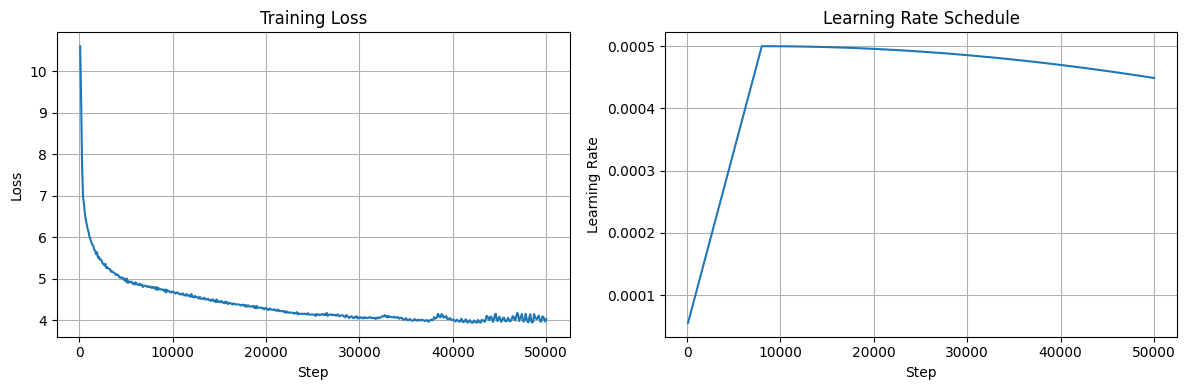


Latest Training Metrics:
   Step: 50000.0
   Loss: 4.0312
   Learning Rate: 0.000449
   GPU Memory: 1347 MB


In [190]:
# Check training progress (if training has started)
import pandas as pd
import matplotlib.pyplot as plt

log_file = Path('checkpoints/training_log.csv')

if log_file.exists():
    df = pd.read_csv(log_file)

    if len(df) > 0:
        print(f"Training Progress: {len(df)} log entries")

        # Plot loss curve
        if 'loss' in df.columns:
            plt.figure(figsize=(12, 4))

            plt.subplot(1, 2, 1)
            plt.plot(df['step'], df['loss'])
            plt.xlabel('Step')
            plt.ylabel('Loss')
            plt.title('Training Loss')
            plt.grid(True)

            if 'learning_rate' in df.columns:
                plt.subplot(1, 2, 2)
                plt.plot(df['step'], df['learning_rate'])
                plt.xlabel('Step')
                plt.ylabel('Learning Rate')
                plt.title('Learning Rate Schedule')
                plt.grid(True)

            plt.tight_layout()
            plt.show()

            # Display latest metrics
            print("\nLatest Training Metrics:")
            latest = df.iloc[-1]
            print(f"   Step: {latest['step']}")
            print(f"   Loss: {latest['loss']:.4f}")
            if 'learning_rate' in latest:
                print(f"   Learning Rate: {latest['learning_rate']:.6f}")
            if 'gpu_memory_mb' in latest:
                print(f"   GPU Memory: {latest['gpu_memory_mb']:.0f} MB")
    else:
        print("Training log is empty")
else:
    print("Training log not found. Training may not have started yet.")


## 5. Resume Pipeline (If Interrupted)


## 6. Download Results (Optional)


In [195]:
# Download results to Google Drive or local machine
from google.colab import files
import shutil
from pathlib import Path

# Option 1: Download specific files
def download_file(file_path):
    """Download a file from Colab."""
    if os.path.exists(file_path):
        files.download(file_path)
        print(f"Downloaded: {file_path}")
    else:
        print(f"File not found: {file_path}")

# Option 2: Copy to Google Drive
def copy_to_drive(source_dir, drive_path="/content/drive/MyDrive/neuroMOE_results"):
    """Copy results to Google Drive with progress tracking."""
    import os
    import shutil
    from pathlib import Path
    
    source = Path(source_dir)
    if not source.exists():
        print(f"Directory not found: {source_dir}")
        return
    
    # Count files before copying
    all_files = [f for f in source.rglob("*") if f.is_file()]
    print(f"Found {len(all_files)} files in {source_dir} to copy")
    
    # Determine destination path
    # If drive_path ends with the source directory name, use it as-is
    # Otherwise, append the source directory name
    drive_path_obj = Path(drive_path)
    if drive_path_obj.name == source.name:
        dest_path = drive_path_obj
    else:
        dest_path = drive_path_obj / source.name
    
    print(f"Copying to: {dest_path}")
    
    # Create destination directory
    dest_path.mkdir(parents=True, exist_ok=True)
    
    # Copy files with progress tracking
    if dest_path.exists() and any(dest_path.iterdir()):
        print(f"   Target directory exists, merging files...")
        # Merge: copy files that don't exist or are newer
        copied_count = 0
        skipped_count = 0
        for item in source.rglob("*"):
            if item.is_file():
                rel_path = item.relative_to(source)
                target_file = dest_path / rel_path
                # Copy if file doesn't exist or source is newer
                if not target_file.exists() or item.stat().st_mtime > target_file.stat().st_mtime:
                    target_file.parent.mkdir(parents=True, exist_ok=True)
                    shutil.copy2(item, target_file)
                    copied_count += 1
                    if copied_count % 500 == 0:
                        print(f"   Copied {copied_count} files...")
                else:
                    skipped_count += 1
        print(f"   Merged: {copied_count} files copied, {skipped_count} files skipped (already exist)")
    else:
        # Fresh copy
        print(f"   Performing fresh copy...")
        shutil.copytree(source, dest_path, dirs_exist_ok=True)
        print(f"   Copied entire directory")
    
    # Verify copy
    copied_files = [f for f in dest_path.rglob("*") if f.is_file()]
    print(f"   Verification: {len(copied_files)} files in destination")
    if len(copied_files) != len(all_files):
        print(f"   WARNING: File count mismatch! Source: {len(all_files)}, Destination: {len(copied_files)}")
        print(f"   This might indicate some files weren't copied or are in nested directories")
    else:
        print(f"   SUCCESS: All {len(all_files)} files copied successfully")
    
    return dest_path
    """Copy results to Google Drive."""
    os.makedirs(drive_path, exist_ok=True)

    if os.path.exists(source_dir):
        dest_path = os.path.join(drive_path, os.path.basename(source_dir))
    else:
        print(f"Directory not found: {source_dir}")

# Example: Download tokenizer
# download_file('data/arxiv/healthcare_tokenizer.model')
# download_file('data/arxiv/healthcare_tokenizer.vocab')

# Example: Copy checkpoints to Drive
copy_to_drive("data", "/content/drive/MyDrive/neuroMOE_results")
copy_to_drive("checkpoints", "/content/drive/MyDrive/neuroMOE_results")


Copied data to /content/drive/MyDrive/neuroMOE_results/data
Copied checkpoints to /content/drive/MyDrive/neuroMOE_results/checkpoints
Uncomment the download/copy commands above to download results


## Notes

- **NeMo Curator**: Only available on Linux (Colab uses Linux, so it will work). On other platforms, the pipeline automatically falls back to basic preprocessing.
- **GPU**: Colab provides free GPU (T4, ~12GB). The pipeline is optimized for this.
- **Storage**: Colab provides ~80GB disk space. For larger datasets, consider mounting Google Drive.
- **Time Limits**: Free Colab sessions have time limits. Use the resume feature to continue training.
- **Checkpoints**: Model checkpoints are saved every 5000 steps. You can resume from the latest checkpoint.

## Troubleshooting

- **Out of Memory**: Reduce `batch_size` or `max_papers` in config.yaml
- **NeMo Curator Errors**: The pipeline will automatically fall back to basic preprocessing
- **Interrupted Training**: Use the resume feature (Step 5) to continue from the last checkpoint
- **Slow Downloads**: ArXiv rate limiting is built-in. Be patient for large collections.
